# Reliance Stock Analysis
**Team 13: INFERENCE ORDER**
•	Yugandhar Gandhavarapu
•	Yogesh Sapkale
•	Yash Patil
•	Yash Daund
•	Yashodhan Agashe
•	Vinit Gharat
•	Vishwatej Shinde


**Stock Name: Reliance Industries Limited (Reliance.NS)**
Reliance Industries Limited engages in the hydrocarbon exploration and production, oil and chemicals, retail, and digital service businesses worldwide. It operates through Oil to Chemicals, Oil and Gas, Retail, Digital Services, and Others segments.


In [ ]:
# Loading Data

In [ ]:
import os       #importing os to set environment variable
def install_java():
  !apt-get install -y openjdk-8-jdk-headless -qq > /dev/null      #install openjdk
  os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"     #set environment variable
  !java -version       #check java version
install_java()

!apt-get update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

import pyspark
from pyspark.sql import SparkSession
from datetime import datetime
from pyspark.sql.types import StructType, StringType, IntegerType, DoubleType, LongType
from pyspark.sql import SparkSession
from pyspark.sql.functions import from_unixtime, explode, col, to_date

spark = SparkSession.builder.appName("").getOrCreate()
sc = spark.sparkContext

openjdk version "17.0.16" 2025-07-15
OpenJDK Runtime Environment (build 17.0.16+8-Ubuntu-0ubuntu122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.16+8-Ubuntu-0ubuntu122.04.1, mixed mode, sharing)
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 https://cli.github.com/packages stable InRelease
Get:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:6 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,532 kB]
Get:11 https://developer.downlo

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

**1. IMPORTING LIBRARIES AND CREATING RDD'S OF DATASET**

In [ ]:
rdd1 = sc.textFile("/content/RELIANCE1.csv")

In [ ]:
for var in rdd1.take(30):
    print(var)

Date,Adj Close,Close,High,Low,Open,Volume
1996-01-01 00:00:00+00:00,3.592268944,7.345901012,7.358397007,7.270925045,7.319124222,104121369
1996-01-02 00:00:00+00:00,3.564334154,7.288775921,7.363752842,7.235221863,7.328050137,168743308
1996-01-03 00:00:00+00:00,3.591395855,7.344116211,7.745775223,7.328050137,7.408380985,209323879
1996-01-04 00:00:00+00:00,3.558222532,7.276279926,7.297701836,7.178096771,7.274495125,216900264
1996-01-05 00:00:00+00:00,3.533779144,7.226295948,7.247717857,7.163815975,7.247717857,166708467
1996-01-08 00:00:00+00:00,3.392358541,6.937100887,7.217370033,6.865695,7.212015152,186974245
1996-01-09 00:00:00+00:00,3.294585466,6.737164021,6.854983807,6.506879807,6.731809139,388766555
1996-01-10 00:00:00+00:00,3.209907055,6.564003944,6.763940811,6.533657074,6.605062962,276606655
1996-01-11 00:00:00+00:00,3.310299873,6.769297123,6.801430225,6.489027977,6.497953892,409645726
1996-01-12 00:00:00+00:00,3.275380373,6.697891235,6.871050835,6.653262138,6.819281101,374687924
1

**2. CREATING DATAFRAME**

In [ ]:
df = spark.read.csv("RELIANCE1.csv", header = True, inferSchema=True)

In [ ]:
df.show()

+-------------------+-----------+-----------+-----------+-----------+-----------+---------+
|               Date|  Adj Close|      Close|       High|        Low|       Open|   Volume|
+-------------------+-----------+-----------+-----------+-----------+-----------+---------+
|1996-01-01 00:00:00|3.592268944|7.345901012|7.358397007|7.270925045|7.319124222|104121369|
|1996-01-02 00:00:00|3.564334154|7.288775921|7.363752842|7.235221863|7.328050137|168743308|
|1996-01-03 00:00:00|3.591395855|7.344116211|7.745775223|7.328050137|7.408380985|209323879|
|1996-01-04 00:00:00|3.558222532|7.276279926|7.297701836|7.178096771|7.274495125|216900264|
|1996-01-05 00:00:00|3.533779144|7.226295948|7.247717857|7.163815975|7.247717857|166708467|
|1996-01-08 00:00:00|3.392358541|6.937100887|7.217370033|   6.865695|7.212015152|186974245|
|1996-01-09 00:00:00|3.294585466|6.737164021|6.854983807|6.506879807|6.731809139|388766555|
|1996-01-10 00:00:00|3.209907055|6.564003944|6.763940811|6.533657074|6.605062962

**3. CLEANING AND PREPROCESSING DATASET**

In [ ]:
df.describe()

DataFrame[summary: string, Adj Close: string, Close: string, High: string, Low: string, Open: string, Volume: string]

In [ ]:
df.printSchema()

root
 |-- Date: timestamp (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- Volume: integer (nullable = true)



In [ ]:
df.createOrReplaceTempView("reliance")

In [ ]:
df = df.withColumnRenamed("Adj Close", "adj_close")
df = df.withColumn("Date", to_date("Date"))

In [ ]:
df.columns

['Date', 'adj_close', 'Close', 'High', 'Low', 'Open', 'Volume']

In [ ]:
df.show()

+----------+-----------+-----------+-----------+-----------+-----------+---------+
|      Date|  adj_close|      Close|       High|        Low|       Open|   Volume|
+----------+-----------+-----------+-----------+-----------+-----------+---------+
|1996-01-01|3.592268944|7.345901012|7.358397007|7.270925045|7.319124222|104121369|
|1996-01-02|3.564334154|7.288775921|7.363752842|7.235221863|7.328050137|168743308|
|1996-01-03|3.591395855|7.344116211|7.745775223|7.328050137|7.408380985|209323879|
|1996-01-04|3.558222532|7.276279926|7.297701836|7.178096771|7.274495125|216900264|
|1996-01-05|3.533779144|7.226295948|7.247717857|7.163815975|7.247717857|166708467|
|1996-01-08|3.392358541|6.937100887|7.217370033|   6.865695|7.212015152|186974245|
|1996-01-09|3.294585466|6.737164021|6.854983807|6.506879807|6.731809139|388766555|
|1996-01-10|3.209907055|6.564003944|6.763940811|6.533657074|6.605062962|276606655|
|1996-01-11|3.310299873|6.769297123|6.801430225|6.489027977|6.497953892|409645726|
|199

In [ ]:
df.describe().show(truncate=False)

+-------+------------------+------------------+------------------+-----------------+------------------+--------------------+
|summary|adj_close         |Close             |High              |Low              |Open              |Volume              |
+-------+------------------+------------------+------------------+-----------------+------------------+--------------------+
|count  |7250              |7250              |7250              |7250             |7250              |7250                |
|mean   |300.63455884735595|317.0605009568081 |320.8774303144755 |313.5327606927793|317.33654605921106|5.9864912218482755E7|
|stddev |391.32262528169247|392.71950275652364|396.67869614761474|389.0687346444079|392.99121402295873|1.0246501359504724E8|
|min    |2.683507919       |5.487557888       |5.487557888       |5.428647995      |5.462564945       |0                   |
|max    |1590.069946       |1600.900024       |1608.800049       |1585.5           |1604.449951       |1448889005          |


**4. CHECKING FOR NULL VALUES**

In [ ]:
spark.sql('''
SELECT
SUM(CASE WHEN Date IS NULL THEN 1 ELSE 0 END) AS Date_NullCount,
SUM(CASE WHEN Open IS NULL THEN 1 ELSE 0 END) AS Open_NullCount,
SUM(CASE WHEN High IS NULL THEN 1 ELSE 0 END) AS High_NullCount,
SUM(CASE WHEN Low IS NULL THEN 1 ELSE 0 END) AS Low_NullCount,
SUM(CASE WHEN Close IS NULL THEN 1 ELSE 0 END) AS Close_NullCount,
SUM(CASE WHEN Volume IS NULL THEN 1 ELSE 0 END) AS Volume_NullCount
FROM reliance
''').show()

+--------------+--------------+--------------+-------------+---------------+----------------+
|Date_NullCount|Open_NullCount|High_NullCount|Low_NullCount|Close_NullCount|Volume_NullCount|
+--------------+--------------+--------------+-------------+---------------+----------------+
|             0|             0|             0|            0|              0|               0|
+--------------+--------------+--------------+-------------+---------------+----------------+



5. CHANGING DATATYPES AND COLUMN NAMES

In [ ]:
df.columns

['Date', 'adj_close', 'Close', 'High', 'Low', 'Open', 'Volume']

In [ ]:
df = df.withColumn("adj_close", col("adj_close").cast("Double"))
df = df.withColumn("Close", col("Close").cast("Double"))
df = df.withColumn("High", col("High").cast("Double"))
df = df.withColumn("Low", col("Low").cast("Double"))
df = df.withColumn("Open", col("Open").cast("Double"))
df = df.withColumn("Volume", col("Volume").cast("Integer"))
df.printSchema()
df.describe()

root
 |-- Date: date (nullable = true)
 |-- adj_close: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- Volume: integer (nullable = true)



DataFrame[summary: string, adj_close: string, Close: string, High: string, Low: string, Open: string, Volume: string]

In [ ]:
df1 = df.filter(df["Volume"] != 0)

In [ ]:
df1.count()

7135

In [ ]:
df1.describe().show()
df.describe().show()

+-------+------------------+------------------+-----------------+------------------+------------------+--------------------+
|summary|         adj_close|             Close|             High|               Low|              Open|              Volume|
+-------+------------------+------------------+-----------------+------------------+------------------+--------------------+
|  count|              7135|              7135|             7135|              7135|              7135|                7135|
|   mean|305.14702015041655|321.72703645398434|325.6054860465686| 318.1424370266251| 322.0075307766784| 6.082979868030834E7|
| stddev| 392.8028578659063| 394.0944662925438|398.0574933739661|390.44022392051227|394.36627229900836|1.0300301922949842E8|
|    min|       2.683507919|       5.487557888|      5.741048813|       5.428647995|       5.462564945|              462151|
|    max|       1590.069946|       1600.900024|      1608.800049|            1585.5|       1604.449951|          1448889005|


6. CREATING VIEW

In [ ]:
df1.createOrReplaceTempView("reliance")
date_check_df = spark.sql('''
SELECT Date
FROM reliance
ORDER BY Date
''')
date_check_df.show(10)

+----------+
|      Date|
+----------+
|1996-01-01|
|1996-01-02|
|1996-01-03|
|1996-01-04|
|1996-01-05|
|1996-01-08|
|1996-01-09|
|1996-01-10|
|1996-01-11|
|1996-01-12|
+----------+
only showing top 10 rows



In [ ]:
#Analysis
from pyspark.sql.window import *
from pyspark.sql.functions import lag, col

**7. ADDING DAILY RETURN PERCENTAGE COLUMN WHICH SHOWS PERCENTAGE INCREASE/DECREASE IN PRICE OF STOCK FOR EACH DAY**

In [ ]:
window_spec = Window.orderBy("Date")

In [ ]:
df_cleaned = df1.withColumn("Daily_Return_percent", (((col("Close") - col("Open")) / col("Open")) * 100))

**8. PLOTTING GRAPH OF CLOSING PRICE OF THE STOCK FOR EACH DAY**

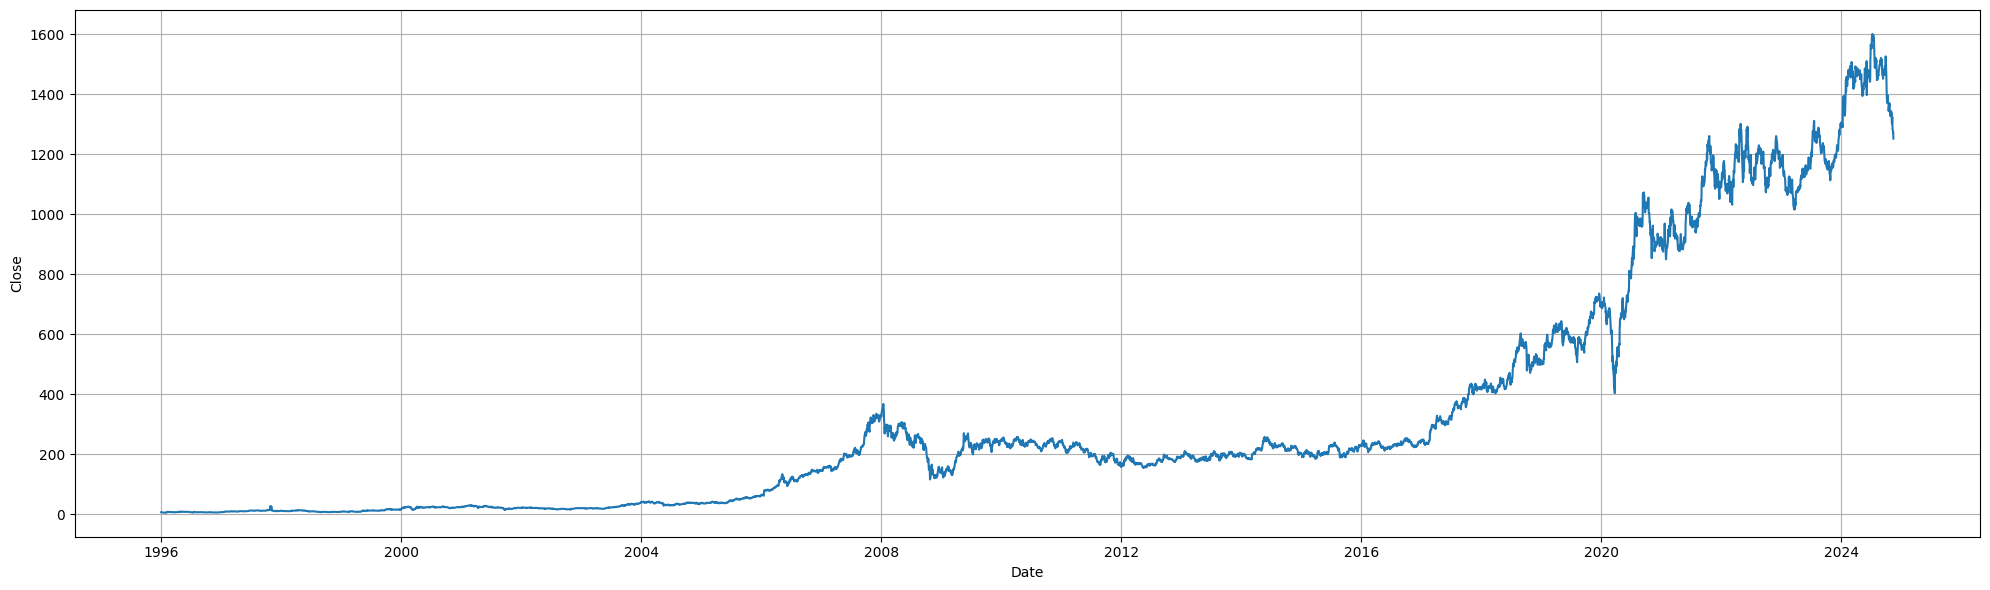

In [ ]:
plot2 = df_cleaned.select("Date", "Close")
pd_df_2 = plot2.toPandas()
plt.figure(figsize=(20, 6))
plt.plot(pd_df_2["Date"], pd_df_2["Close"])
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.tight_layout()

**9. PLOTTING GRAPH WHICH SHOWS DAILY VOLUME FOR EACH DATE**

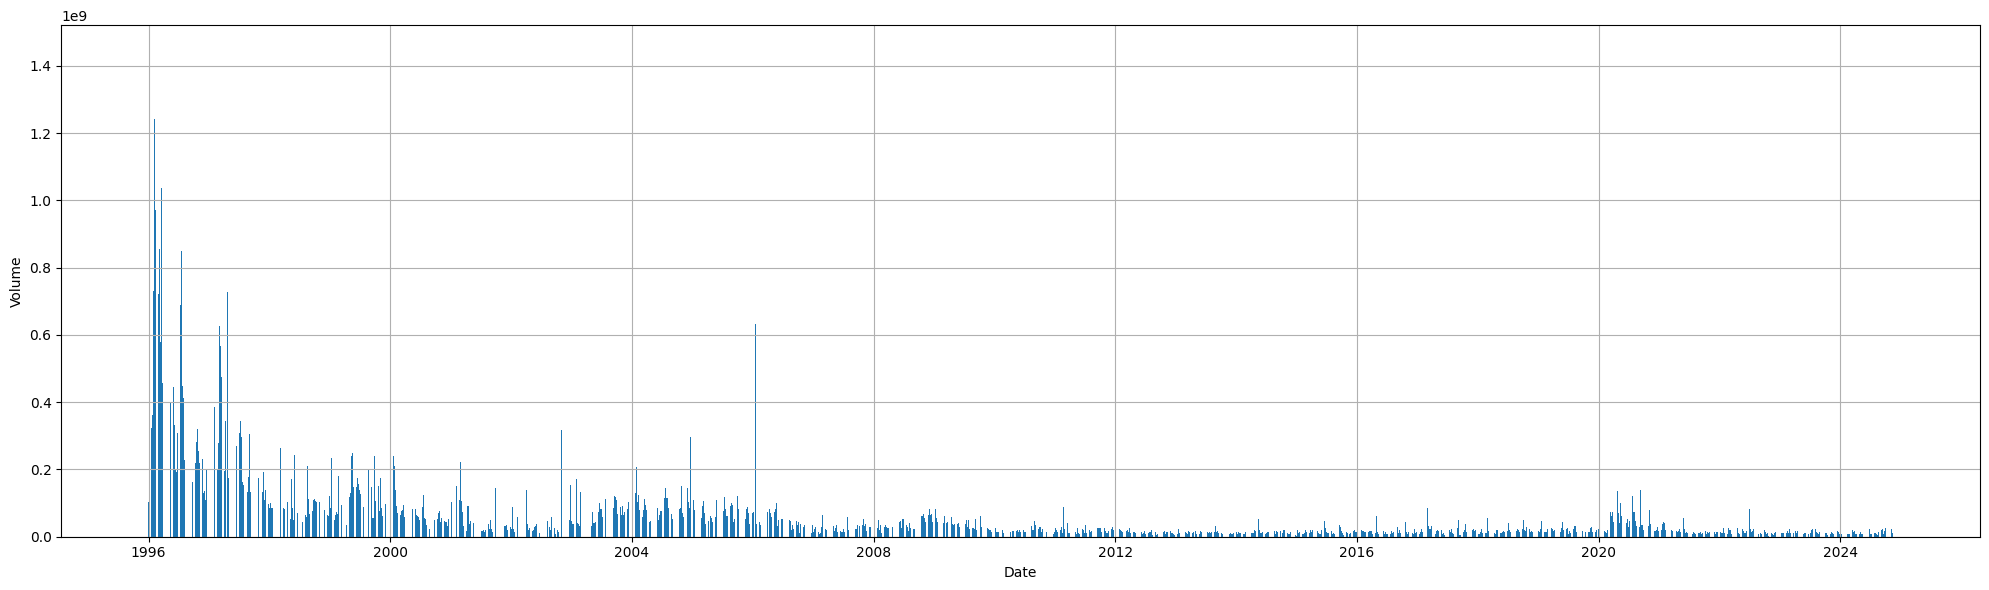

In [ ]:
plot3 = df_cleaned.select("Date", "Volume")
pd_df_3 = plot3.toPandas()
plt.figure(figsize=(20, 6))
plt.bar(pd_df_3["Date"], pd_df_3["Volume"])
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.tight_layout()

10. ADDED DAILY RETURN COLUMN WHICH SHOWS CHANGE IN THE PRICE OF STOCK PER DAY (*CLOSE - OPEN*) **bold text**

In [ ]:
from pyspark.sql.functions import round, col
df_cleaned = df_cleaned.withColumn("Daily_Return", round(col("Close") - col("Open"), 4))

In [ ]:
df_cleaned.show()


+----------+-----------+-----------+-----------+-----------+-----------+---------+--------------------+------------+
|      Date|  adj_close|      Close|       High|        Low|       Open|   Volume|Daily_Return_percent|Daily_Return|
+----------+-----------+-----------+-----------+-----------+-----------+---------+--------------------+------------+
|1996-01-01|3.592268944|7.345901012|7.358397007|7.270925045|7.319124222|104121369|  0.3658469126608513|      0.0268|
|1996-01-02|3.564334154|7.288775921|7.363752842|7.235221863|7.328050137|168743308| -0.5359436039022275|     -0.0393|
|1996-01-03|3.591395855|7.344116211|7.745775223|7.328050137|7.408380985|209323879| -0.8674604360941859|     -0.0643|
|1996-01-04|3.558222532|7.276279926|7.297701836|7.178096771|7.274495125|216900264|0.024535049777771836|      0.0018|
|1996-01-05|3.533779144|7.226295948|7.247717857|7.163815975|7.247717857|166708467| -0.2955676451906874|     -0.0214|
|1996-01-08|3.392358541|6.937100887|7.217370033|   6.865695|7.21

**11. GRAPH OF DAILY RETURN PERCENTAGE PER DAY**

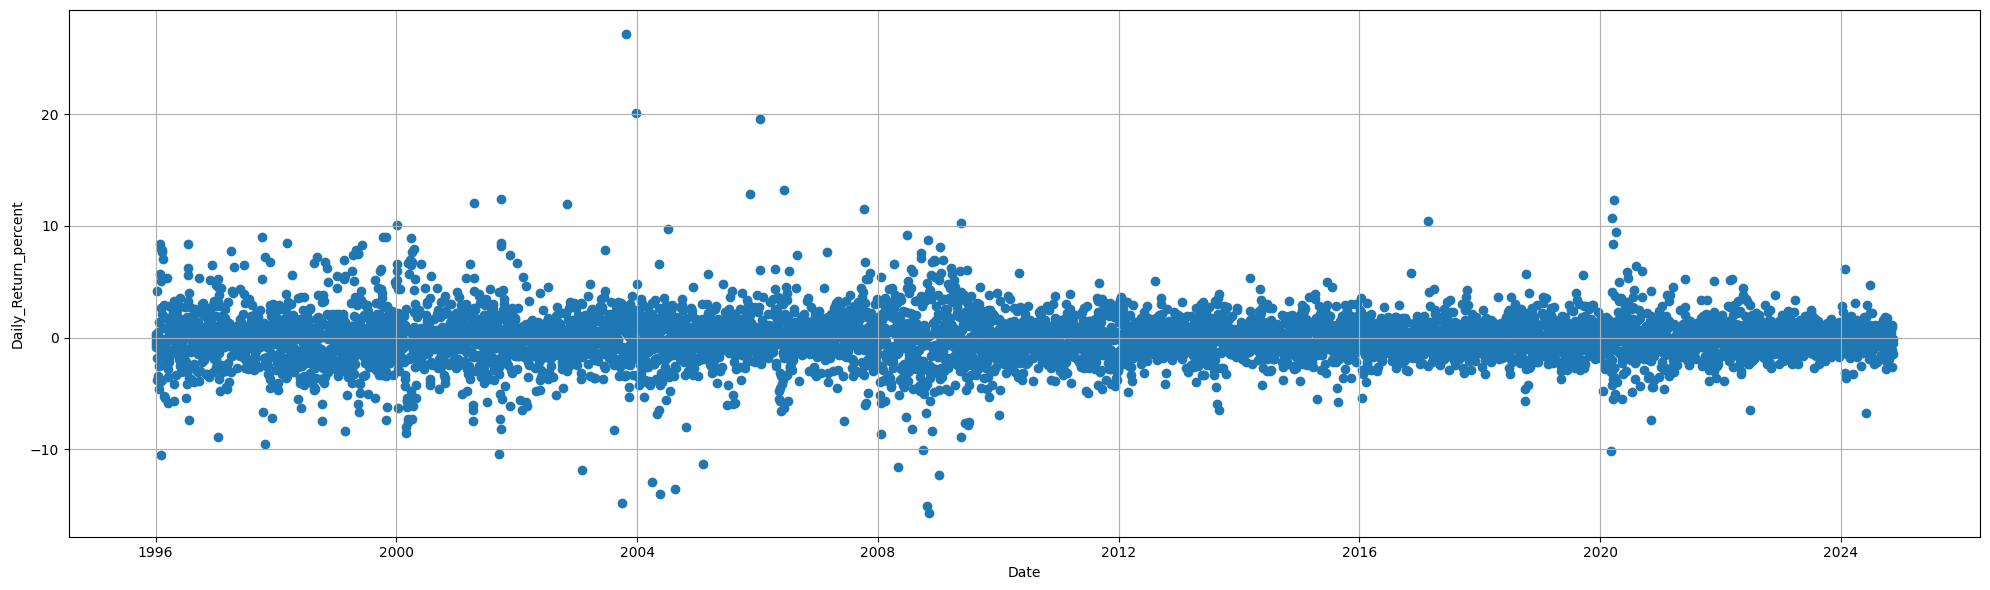

In [ ]:
plot1 = df_cleaned.select("Date", "Daily_Return_percent")
pd_df_1 = plot1.toPandas()
plt.figure(figsize=(20, 6))
plt.scatter(pd_df_1["Date"], pd_df_1["Daily_Return_percent"])
plt.xlabel("Date")
plt.ylabel("Daily_Return_percent")
plt.grid(True)
plt.tight_layout()

12. CREATED TWO WINDOWS "SMA_50" AND "SMA_200"

SMA_50 : CALCULATES THE SIMPLE MOVING AVERAGE BASED ON CLOSING VALUE OVER A 50 DAYS PERIOD , THIS GIVES US SHORT-TERM PERFORMANCE OF THE STOCK

SMA_200 : CALCULATES THE SIMPLE MOVING AVERAGE BASED ON CLOSING VALUE OVER A 200 DAYS PERIOD,THIS GIVES US LONG-TERM PERFORMANCE OF THE STOCKA

In [ ]:
window_50 = Window.orderBy("Date").rowsBetween(-49, 0) # 50-day window
window_200 = Window.orderBy("Date").rowsBetween(-199, 0) # 200-day window
from pyspark.sql.functions import avg

In [ ]:
df_cleaned = df_cleaned.withColumn("SMA_50", avg("Close").over(window_50))
df_cleaned = df_cleaned.withColumn("SMA_200", avg("Close").over(window_200))
df_cleaned.show()

+----------+-----------+-----------+-----------+-----------+-----------+---------+--------------------+------------+-----------------+-----------------+
|      Date|  adj_close|      Close|       High|        Low|       Open|   Volume|Daily_Return_percent|Daily_Return|           SMA_50|          SMA_200|
+----------+-----------+-----------+-----------+-----------+-----------+---------+--------------------+------------+-----------------+-----------------+
|1996-01-01|3.592268944|7.345901012|7.358397007|7.270925045|7.319124222|104121369|  0.3658469126608513|      0.0268|      7.345901012|      7.345901012|
|1996-01-02|3.564334154|7.288775921|7.363752842|7.235221863|7.328050137|168743308| -0.5359436039022275|     -0.0393|     7.3173384665|     7.3173384665|
|1996-01-03|3.591395855|7.344116211|7.745775223|7.328050137|7.408380985|209323879| -0.8674604360941859|     -0.0643|7.326264381333334|7.326264381333334|
|1996-01-04|3.558222532|7.276279926|7.297701836|7.178096771|7.274495125|216900264|

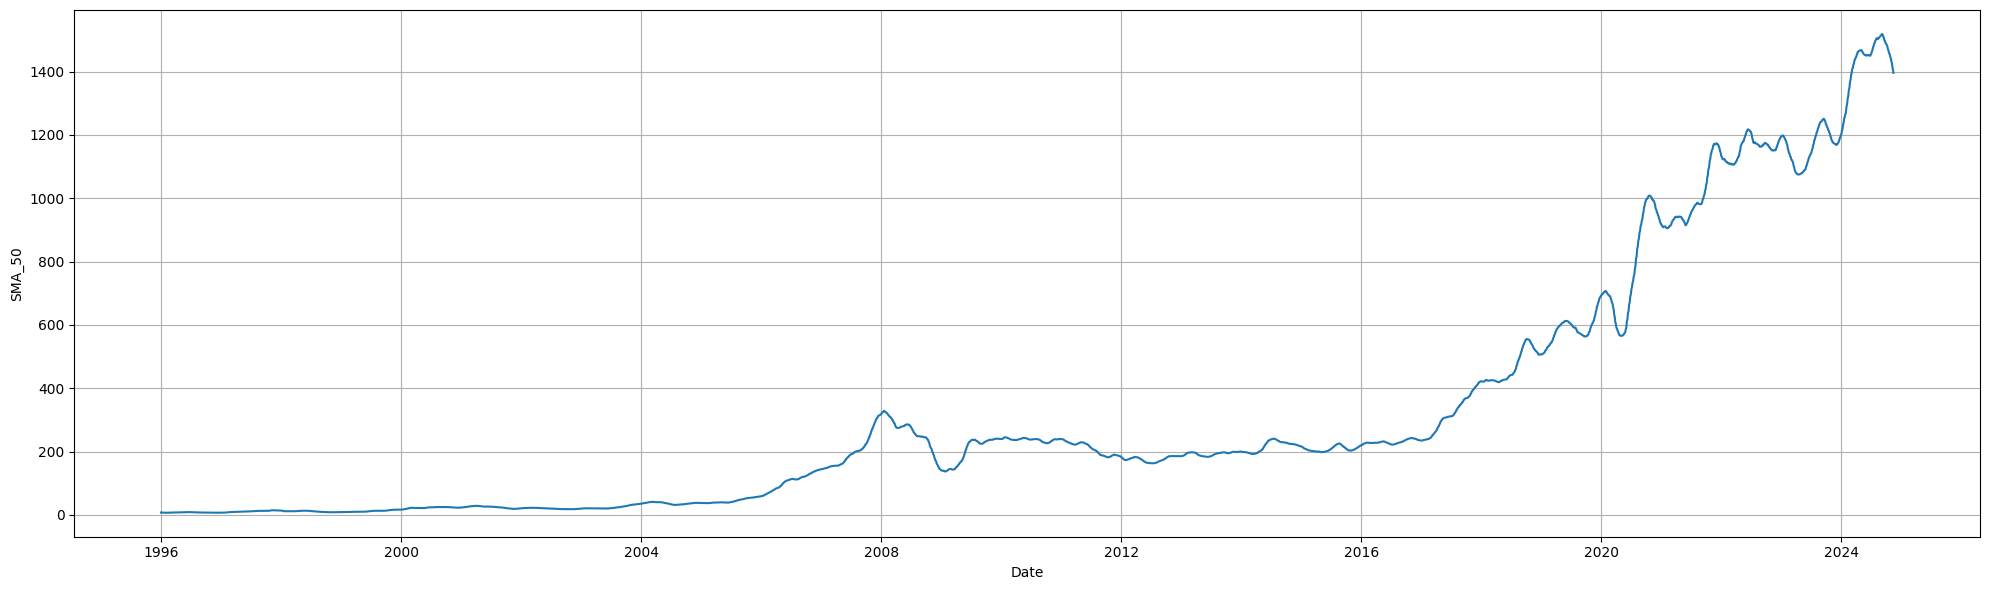

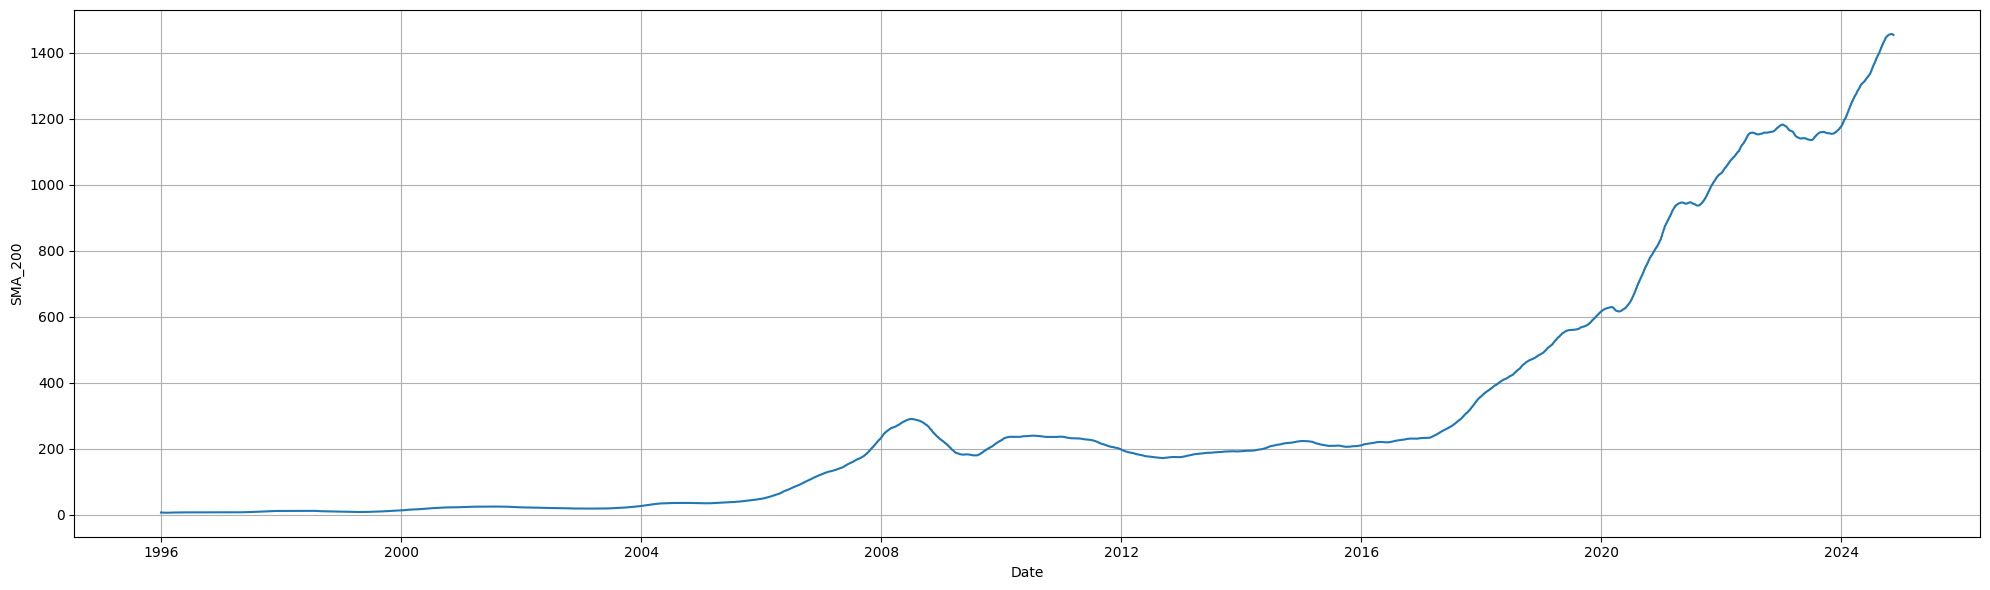

In [ ]:
plot3 = df_cleaned.select("Date", "SMA_50")
pd_df_3 = plot3.toPandas()
plt.figure(figsize=(20, 6))
plt.plot(pd_df_3["Date"], pd_df_3["SMA_50"])
plt.xlabel("Date")
plt.ylabel("SMA_50")
plt.grid(True)
plt.tight_layout()

plot4 = df_cleaned.select("Date", "SMA_200")
pd_df_4 = plot4.toPandas()
plt.figure(figsize=(20, 6))
plt.plot(pd_df_4["Date"], pd_df_4["SMA_200"])
plt.xlabel("Date")
plt.ylabel("SMA_200")
plt.grid(True)
plt.tight_layout()

In [ ]:
df_cleaned.show()

+----------+-----------+-----------+-----------+-----------+-----------+---------+--------------------+------------+-----------------+-----------------+
|      Date|  adj_close|      Close|       High|        Low|       Open|   Volume|Daily_Return_percent|Daily_Return|           SMA_50|          SMA_200|
+----------+-----------+-----------+-----------+-----------+-----------+---------+--------------------+------------+-----------------+-----------------+
|1996-01-01|3.592268944|7.345901012|7.358397007|7.270925045|7.319124222|104121369|  0.3658469126608513|      0.0268|      7.345901012|      7.345901012|
|1996-01-02|3.564334154|7.288775921|7.363752842|7.235221863|7.328050137|168743308| -0.5359436039022275|     -0.0393|     7.3173384665|     7.3173384665|
|1996-01-03|3.591395855|7.344116211|7.745775223|7.328050137|7.408380985|209323879| -0.8674604360941859|     -0.0643|7.326264381333334|7.326264381333334|
|1996-01-04|3.558222532|7.276279926|7.297701836|7.178096771|7.274495125|216900264|

14. CREATED NEW TEMPVIEW FOR UPDATED COLUMNS

In [ ]:
df_cleaned.createOrReplaceTempView("reliance")

**15. SQL QUERY SHOWING STATISTCS ABOUT CLOSE AND VOLUME**

In [ ]:
spark.sql('''
SELECT
MIN(Close) AS Min_Close,
MAX(Close) AS Max_Close,
AVG(Close) AS Avg_Close,
STDDEV(Close) AS StdDev_Close,
MIN(Volume) AS Min_Volume,
MAX(Volume) AS Max_Volume,
AVG(Volume) AS Avg_Volume,
STDDEV(Volume) AS StdDev_Volume
FROM reliance
''').show()

+-----------+-----------+------------------+-----------------+----------+----------+-------------------+--------------------+
|  Min_Close|  Max_Close|         Avg_Close|     StdDev_Close|Min_Volume|Max_Volume|         Avg_Volume|       StdDev_Volume|
+-----------+-----------+------------------+-----------------+----------+----------+-------------------+--------------------+
|5.487557888|1600.900024|321.72703645398434|394.0944662925438|    462151|1448889005|6.082979868030834E7|1.0300301922949842E8|
+-----------+-----------+------------------+-----------------+----------+----------+-------------------+--------------------+



16. GRAPH SHOWING RELATION BETWEEN CLOSING VALUE AND VOLUME

*LESSER VOLUME INDICATES HIGER CLOSING VALUES*

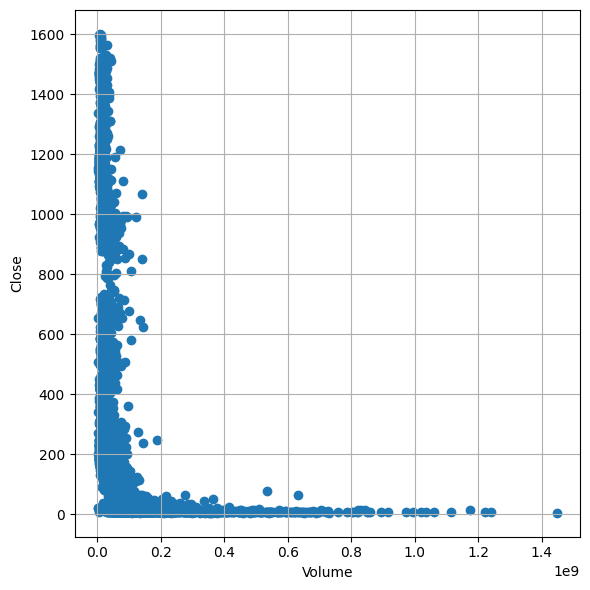

In [ ]:
plot5 = df_cleaned.select("Volume", "Close")
pd_df_5 = plot5.toPandas()
plt.figure(figsize=(6, 6))
plt.scatter(pd_df_5["Volume"], pd_df_5["Close"])
plt.xlabel("Volume")
plt.ylabel("Close")
plt.grid(True)
plt.tight_layout()

**17. CALCULATED STANDARD DEVIATION OF DAILY RETURN (PERCENT)**

+--------------------+-------------------+-------------------+-----------------+
|    Avg_Daily_Return|Daily_Return_StdDev|   Min_Daily_Return| Max_Daily_Return|
+--------------------+-------------------+-------------------+-----------------+
|-0.08154358377635289|  2.161273272376127|-15.688937374141092|27.20270303989793|
+--------------------+-------------------+-------------------+-----------------+



Text(0.5, 1.0, 'Summary of Daily Return Percent')

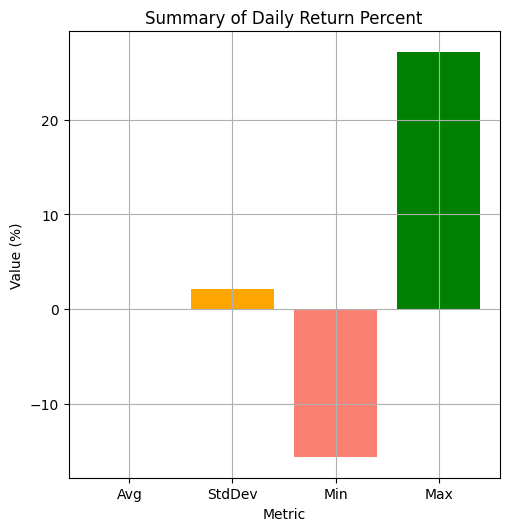

In [ ]:
spark.sql('''
SELECT
AVG(Daily_Return_percent) AS Avg_Daily_Return,
STDDEV(Daily_Return_percent) AS Daily_Return_StdDev,
MIN(Daily_Return_percent) AS Min_Daily_Return,
MAX(Daily_Return_percent) AS Max_Daily_Return
FROM reliance
''').show()

avg_return = -0.08154358377635289
stddev_return = 2.161273272376127
min_return = -15.688937374141092
max_return = 27.20270303989793

metrics = ['Avg', 'StdDev', 'Min', 'Max']
values = [avg_return, stddev_return, min_return, max_return]
colors = ['skyblue', 'orange', 'salmon', 'green']

plt.figure(figsize=(5, 5))
plt.bar(metrics, values, color=colors)
plt.grid(True)
plt.tight_layout()
plt.xlabel('Metric')
plt.ylabel('Value (%)')
plt.title('Summary of Daily Return Percent')

18. SQL QUERY TO ANALYSE IF THAT STOCK WAS *BEARISH* OR *BULLISH* FOR THAT DAY.

IF SMA_50 > SMA_200 IT INDICATES BULLISH TREND OTHERWISE BEARISH TREND **bold text**

In [ ]:
spark.sql('''
SELECT
Date,
Close,
SMA_50,
SMA_200,
CASE WHEN SMA_50 > SMA_200 THEN "Bullish" ELSE "Bearish" END AS Trend
FROM reliance
ORDER BY Date
''').show(10)

from pyspark.sql.functions import when, col

df_cleaned = df_cleaned.withColumn(
    "Trend",
    when(col("SMA_50") > col("SMA_200"), "Bullish").otherwise("Bearish")
)

# - Uptrend:
# When the 50-day SMA is above the 200-day SMA, it suggests that recent prices are rising faster than the long-term average.
# → Traders often see this as a bullish signal, indicating strength and potential for further gains.
# - Downtrend:
# When the 50-day SMA is below the 200-day SMA, it suggests that recent prices are lagging behind the long-term average.
# → This is considered a bearish signal, indicating weakness or potential decline.


+----------+-----------+-----------------+-----------------+-------+
|      Date|      Close|           SMA_50|          SMA_200|  Trend|
+----------+-----------+-----------------+-----------------+-------+
|1996-01-01|7.345901012|      7.345901012|      7.345901012|Bearish|
|1996-01-02|7.288775921|     7.3173384665|     7.3173384665|Bearish|
|1996-01-03|7.344116211|7.326264381333334|7.326264381333334|Bearish|
|1996-01-04|7.276279926|     7.3137682675|     7.3137682675|Bearish|
|1996-01-05|7.226295948|     7.2962738036|     7.2962738036|Bearish|
|1996-01-08|6.937100887|7.236411650833333|7.236411650833333|Bearish|
|1996-01-09|6.737164021|7.165090560857143|7.165090560857143|Bearish|
|1996-01-10|6.564003944|    7.08995473375|    7.08995473375|Bearish|
|1996-01-11|6.769297123|7.054326110333333|7.054326110333333|Bearish|
|1996-01-12|6.697891235|     7.0186826228|     7.0186826228|Bearish|
+----------+-----------+-----------------+-----------------+-------+
only showing top 10 rows



**18. GRAPH SHOWING BULLISH AND BEARISH TRENDS**

RED: BEARISH    

GREEN: BULLISH

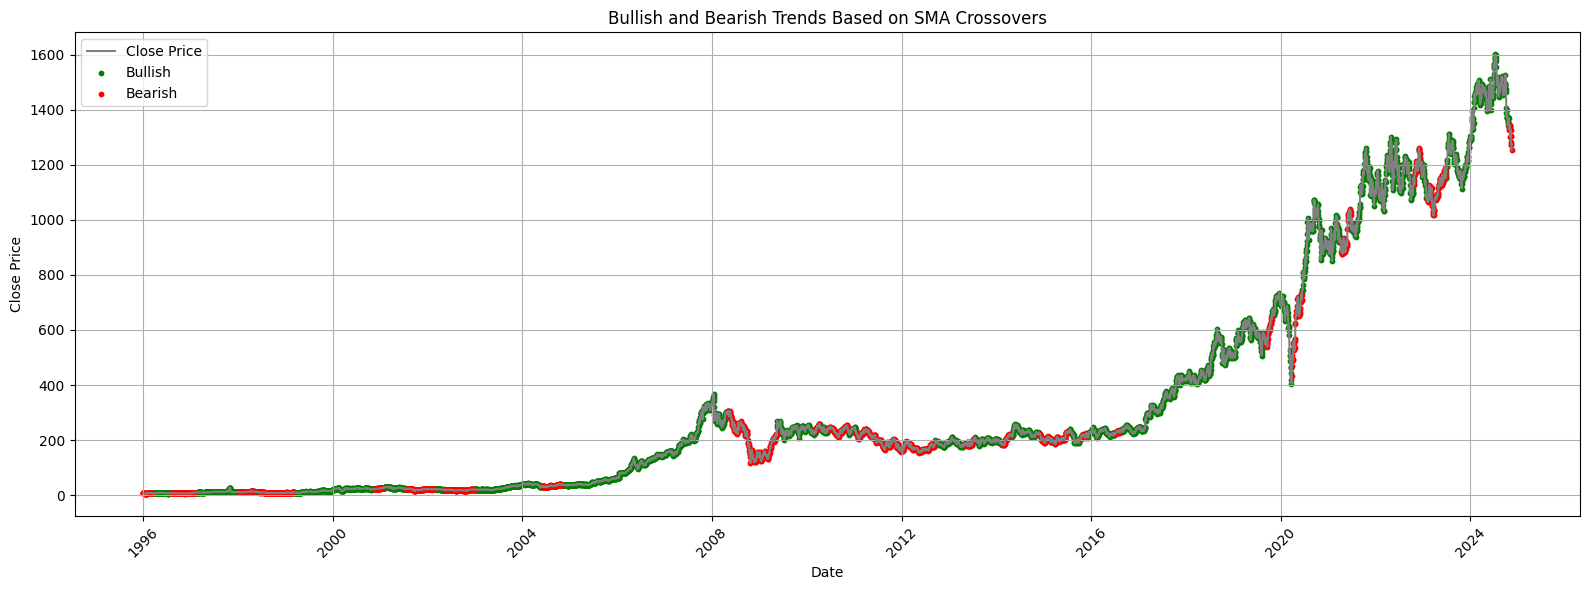

In [ ]:
df_trends = df_cleaned.select("Date", "Close", "Trend").toPandas()

# Sort by date
df_trends = df_trends.sort_values('Date')

# Plot the full Close price line in gray
plt.figure(figsize=(16, 6))
plt.plot(df_trends['Date'], df_trends['Close'], color='gray', label='Close Price')

# Overlay Bullish and Bearish markers
bullish = df_trends[df_trends['Trend'] == 'Bullish']
bearish = df_trends[df_trends['Trend'] == 'Bearish']

plt.scatter(bullish['Date'], bullish['Close'], color='green', label='Bullish', s=10)
plt.scatter(bearish['Date'], bearish['Close'], color='red', label='Bearish', s=10)

# Labels and title
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Bullish and Bearish Trends Based on SMA Crossovers')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

19. GRAPH SHOWING CANDLESTICKS TO REPRESENTS DIFFRENCE BETWEEN OPENING AND CLOSING PRICE

GREEN: INDIACATES UPWARD TREND

RED: INDIACATES DOWNWARD TREND

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


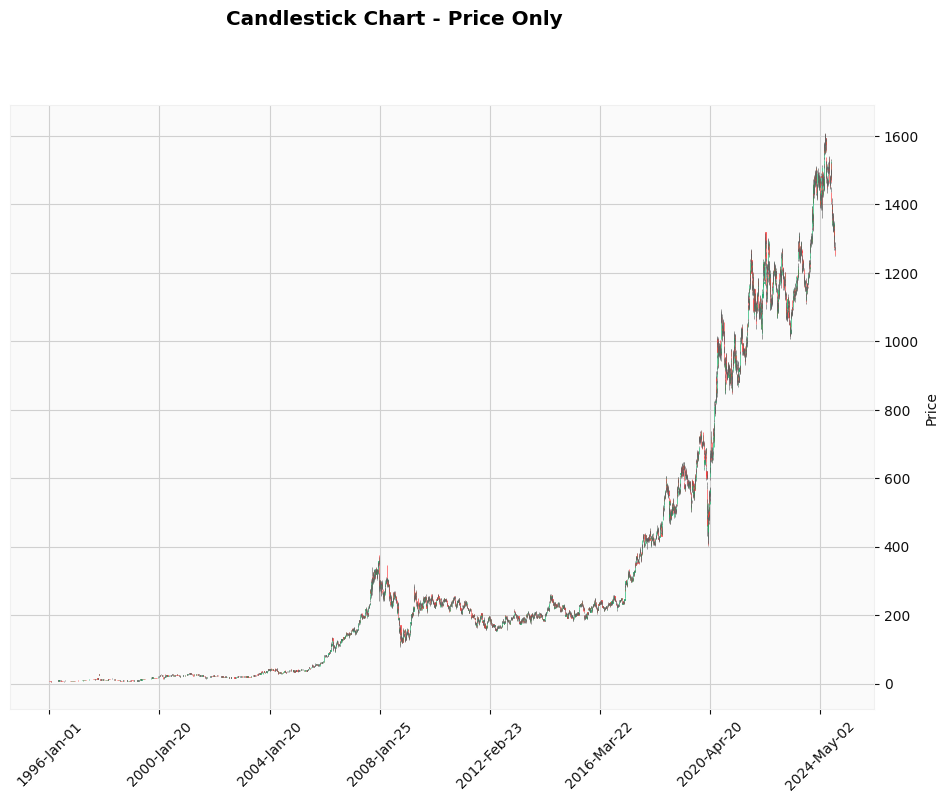

In [ ]:
!pip install mplfinance
import pandas as pd
import mplfinance as mpf

# Convert Spark DataFrame to Pandas
df_candle = df_cleaned.select("Date", "Open", "High", "Low", "Close").toPandas()

# Ensure Date is datetime and set as index
df_candle['Date'] = pd.to_datetime(df_candle['Date'])
df_candle.set_index('Date', inplace=True)

# Plot candlestick chart without volume
mpf.plot(df_candle, type='candle', style='yahoo', title='Candlestick Chart - Price Only', volume=False, figscale =1.5)

# - Body: The thick part between the open and close prices
# - Green (or white): Close > Open → price went up
# - Red (or black): Close < Open → price went down
# - Wicks (or shadows): Thin lines above and below the body
# - Upper wick: Shows the highest price
# - Lower wick: Shows the lowest price


**20. SHOWS THE HIGEST VOLUME TRENDS**

In [ ]:
spark.sql('''
SELECT
Date,
Volume,
Close,
Daily_Return_percent
FROM reliance
ORDER BY Volume DESC
LIMIT 10
''').show()

In [ ]:
plot6 = df_cleaned.select("Volume", "Daily_Return_percent")
pd_df_6 = plot6.toPandas()
plt.figure(figsize=(6, 6))
plt.scatter(pd_df_6["Volume"], pd_df_6["Daily_Return_percent"])
plt.xlabel("Volume")
plt.ylabel("Daily_Return_percent")
plt.grid(True)
plt.tight_layout()

**21. MONTHWISE AVERAGE OF CLOSING PRICE AND VOLUME**

In [ ]:
from pyspark.sql.functions import month
df_monthly = df_cleaned.withColumn("Month", month("Date"))
df_monthly.groupBy("Month").avg("Close", "Volume").orderBy("Month").show()

+-----+------------------+--------------------+
|Month|        avg(Close)|         avg(Volume)|
+-----+------------------+--------------------+
|    1| 302.9518366988612| 6.774885794281046E7|
|    2| 306.6042021501647| 7.317933141330998E7|
|    3| 298.3782682589101| 7.170671035144313E7|
|    4|  310.563456052123| 6.596217258589512E7|
|    5|313.89380912150017|6.3847930040584415E7|
|    6|322.17978299077595| 6.459804668668831E7|
|    7| 331.5107023747942| 6.695020817425432E7|
|    8|339.34751922244664|4.9284413223316915E7|
|    9|345.59152048928826|5.1371962471666664E7|
|   10|348.90296868810583| 6.049213202946274E7|
|   11|327.53091066745037|4.9119533831560284E7|
|   12|312.18755026562286| 4.542438879864636E7|
+-----+------------------+--------------------+



In [ ]:
#using sql
spark.sql('''
SELECT
MONTH(Date) AS Month,
AVG(Close) AS Avg_Monthly_Close,
AVG(Volume) AS Avg_Monthly_Volume
FROM reliance
GROUP BY MONTH(Date)
ORDER BY Month
''').show()

+-----+------------------+--------------------+
|Month| Avg_Monthly_Close|  Avg_Monthly_Volume|
+-----+------------------+--------------------+
|    1| 302.9518366988612| 6.774885794281046E7|
|    2| 306.6042021501647| 7.317933141330998E7|
|    3| 298.3782682589101| 7.170671035144313E7|
|    4|  310.563456052123| 6.596217258589512E7|
|    5|313.89380912150017|6.3847930040584415E7|
|    6|322.17978299077595| 6.459804668668831E7|
|    7| 331.5107023747942| 6.695020817425432E7|
|    8|339.34751922244664|4.9284413223316915E7|
|    9|345.59152048928826|5.1371962471666664E7|
|   10|348.90296868810583| 6.049213202946274E7|
|   11|327.53091066745037|4.9119533831560284E7|
|   12|312.18755026562286| 4.542438879864636E7|
+-----+------------------+--------------------+



22. SHOWS THE TOP 10 DAYS WITH THE MOST SIGNIFICANT DAILY RETURNS INDICATING HIGH VOLATILITY (DRASTIC CHANGE IN PRICE OF STOCK)

In [ ]:
spark.sql('''
SELECT
Date,
Close,
Daily_Return_percent
FROM reliance
ORDER BY ABS(Daily_Return_percent) DESC
LIMIT 10
''').show()

+----------+-----------+--------------------+
|      Date|      Close|Daily_Return_percent|
+----------+-----------+--------------------+
|2003-10-24|33.60727692|   27.20270303989793|
|2003-12-23|37.30253983|   20.09194825975197|
|2006-01-18|79.28407288|   19.58282404276746|
|2008-11-05| 145.041748| -15.688937374141092|
|2008-10-24|116.5202713| -15.041666566320261|
|2003-09-29|31.01166534| -14.843137717995031|
|2004-05-17|28.86948204| -13.978726892405119|
|2004-08-17|34.24636078|  -13.58558286318592|
|2006-06-09|105.4625626|  13.220858870796187|
|2004-04-02|40.40156555| -12.953848399854781|
+----------+-----------+--------------------+



**23. CORRELATION BETWEEN VARIOUS COLUMNS SHOWCASING HOW CONSISTENTLY THOSE VALUES MOVE TOGETHER  **

In [ ]:
spark.sql('''
SELECT
corr(Open, Close) AS Open_Close_Correlation,
corr(High, Close) AS High_Close_Correlation,
corr(Low, Close) AS Low_Close_Correlation,
corr(Volume, Close) AS Volume_Close_Correlation
FROM reliance
''').show()

+----------------------+----------------------+---------------------+------------------------+
|Open_Close_Correlation|High_Close_Correlation|Low_Close_Correlation|Volume_Close_Correlation|
+----------------------+----------------------+---------------------+------------------------+
|    0.9998131743453953|    0.9999241195252221|   0.9999198481804579|    -0.31333080328357055|
+----------------------+----------------------+---------------------+------------------------+



24. VISUALISATION OF HIGH AND LOW PRICES AND OPEN AND CLOSE

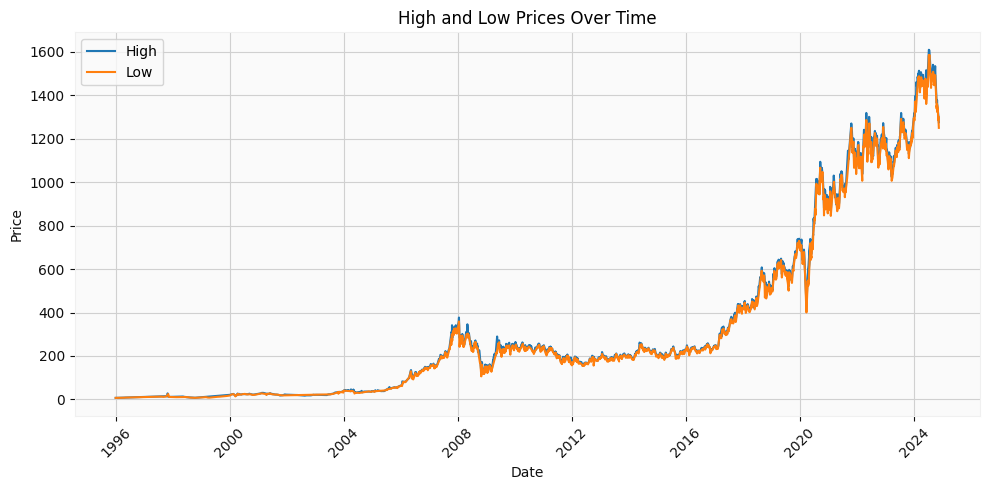

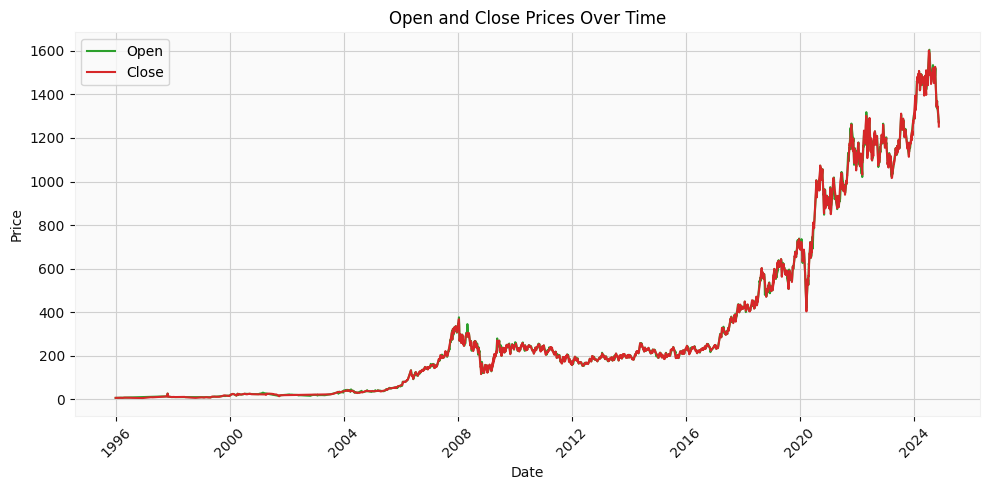

In [ ]:
# Convert Spark DataFrame to Pandas
pd_df_7 = df_cleaned.select("Date", "Open", "High", "Low", "Close").toPandas()

# Ensure Date is datetime and sort
pd_df_7['Date'] = pd.to_datetime(pd_df_7['Date'])
pd_df_7 = pd_df_7.sort_values('Date')

# First Chart: High and Low
plt.figure(figsize=(10, 5))
plt.plot(pd_df_7['Date'], pd_df_7['High'], label='High', color='#1f77b4')  # Bright blue
plt.plot(pd_df_7['Date'], pd_df_7['Low'], label='Low', color='#ff7f0e')   # Bright orange
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('High and Low Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Second Chart: Open and Low
plt.figure(figsize=(10, 5))
plt.plot(pd_df_7['Date'], pd_df_7['Open'], label='Open', color='#2ca02c')  # Bright green
plt.plot(pd_df_7['Date'], pd_df_7['Close'], label='Close', color='#d62728')    # Bright red
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Open and Close Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

25. ADDED STANDARD DEVIATION COLUMNS OF 30 DAYS

In [ ]:
from pyspark.sql.functions import stddev
window_30 = Window.orderBy("Date").rowsBetween(-29, 0)

df_cleaned = df_cleaned.withColumn("Volatility_30",
stddev("Daily_Return_percent").over(window_30))
df_cleaned = df_cleaned.na.fill({"Volatility_30": 0})

In [ ]:
df_cleaned.show()

+----------+-----------+-----------+-----------+-----------+-----------+---------+--------------------+------------+-----------------+-----------------+-------+-------------------+
|      Date|  adj_close|      Close|       High|        Low|       Open|   Volume|Daily_Return_percent|Daily_Return|           SMA_50|          SMA_200|  Trend|      Volatility_30|
+----------+-----------+-----------+-----------+-----------+-----------+---------+--------------------+------------+-----------------+-----------------+-------+-------------------+
|1996-01-01|3.592268944|7.345901012|7.358397007|7.270925045|7.319124222|104121369|  0.3658469126608513|      0.0268|      7.345901012|      7.345901012|Bearish|                0.0|
|1996-01-02|3.564334154|7.288775921|7.363752842|7.235221863|7.328050137|168743308| -0.5359436039022275|     -0.0393|     7.3173384665|     7.3173384665|Bearish| 0.6376621894714727|
|1996-01-03|3.591395855|7.344116211|7.745775223|7.328050137|7.408380985|209323879| -0.867460436

**26. GRAPH SHOWING VOLATILITY OF STOCK BASED ON STANDARD DEVIATION **

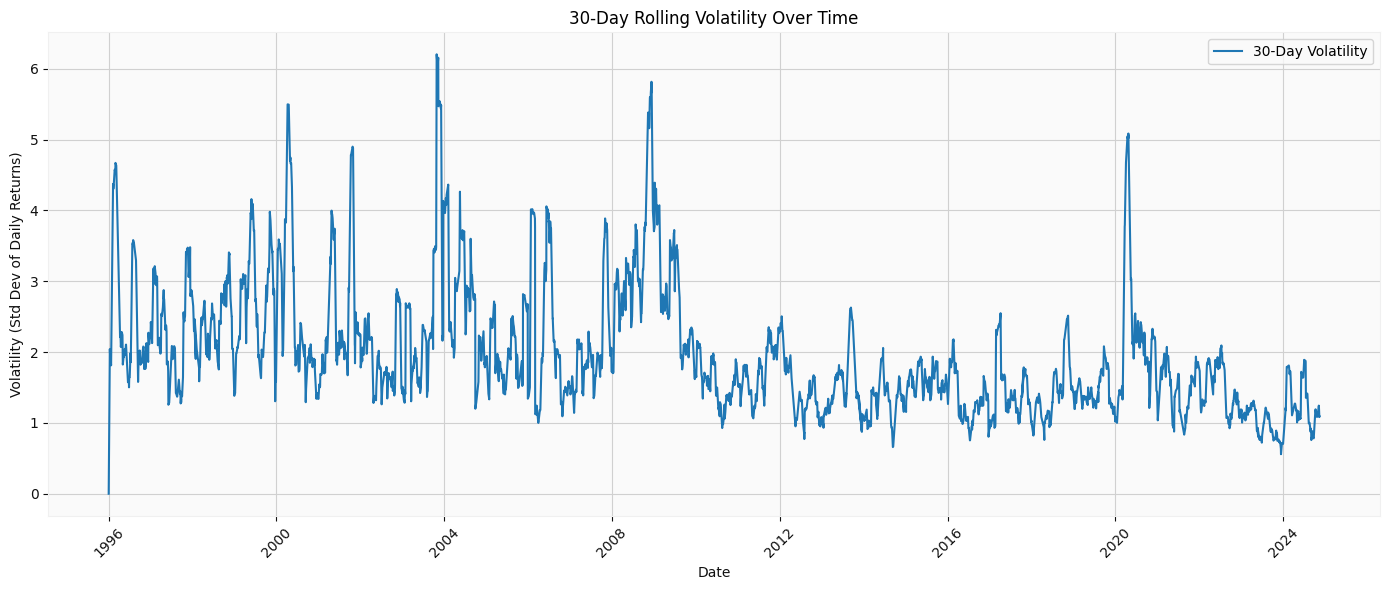

In [ ]:
pd_df_vol = df_cleaned.select("Date", "Volatility_30").toPandas()

# Ensure Date is datetime and sort
pd_df_vol['Date'] = pd.to_datetime(pd_df_vol['Date'])
pd_df_vol = pd_df_vol.sort_values('Date')

# Plot
plt.figure(figsize=(14, 6))
plt.plot(pd_df_vol['Date'], pd_df_vol['Volatility_30'], color='#1f77b4', label='30-Day Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev of Daily Returns)')
plt.title('30-Day Rolling Volatility Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


27. GRAPH AVERAGE CLOSING PRICE PER MONTH

GRAPH INCREASES DURING FIRST AND SECOND QUARTER AND DECREASES DURING THIRD AND FOURTH QUARTER

In [ ]:
spark.sql('''
SELECT
MONTH(Date) AS Month,
AVG(Close) AS Avg_Close
FROM reliance
GROUP BY MONTH(Date)
ORDER BY Month
''').show()

+-----+------------------+
|Month|         Avg_Close|
+-----+------------------+
|    1| 302.9518366988612|
|    2| 306.6042021501647|
|    3| 298.3782682589101|
|    4|  310.563456052123|
|    5|313.89380912150017|
|    6|322.17978299077595|
|    7| 331.5107023747942|
|    8|339.34751922244664|
|    9|345.59152048928826|
|   10|348.90296868810583|
|   11|327.53091066745037|
|   12|312.18755026562286|
+-----+------------------+



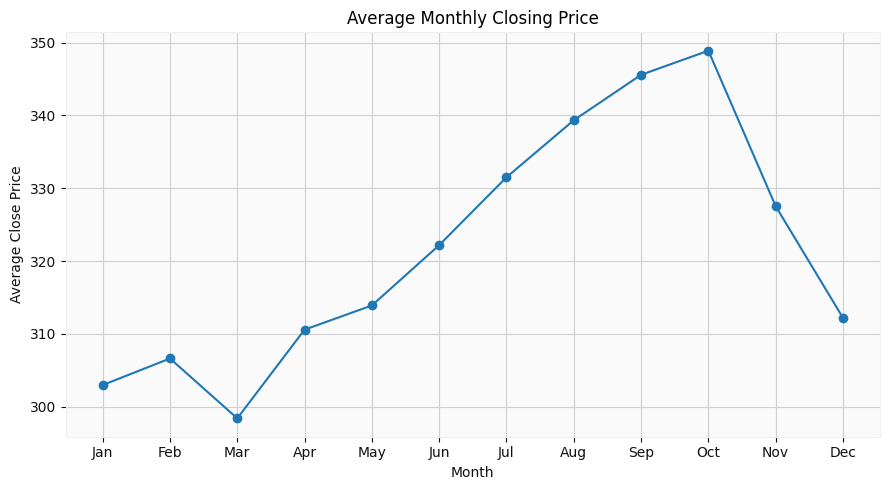

In [ ]:
pd_df_monthly = df_cleaned.select("Date", "Close").toPandas()

pd_df_monthly['Date'] = pd.to_datetime(pd_df_monthly['Date'])

pd_df_monthly['Month'] = pd_df_monthly['Date'].dt.month
monthly_avg = pd_df_monthly.groupby('Month')['Close'].mean().reset_index()

plt.figure(figsize=(9, 5))
plt.plot(monthly_avg['Month'], monthly_avg['Close'], marker='o', linestyle='-', color='#1f77b4')
plt.xlabel('Month')
plt.ylabel('Average Close Price')
plt.title('Average Monthly Closing Price')
plt.xticks(ticks=range(1, 13), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])
plt.grid(True)
plt.tight_layout()
plt.show()

28. FINDING DAYS WITH SIGNIFICANT PRICE MOVEMENTS

In [ ]:
spark.sql('''
SELECT
Date,
Close,
Daily_Return_percent
FROM reliance
WHERE ABS(Daily_Return_percent) > (SELECT AVG(Daily_Return_percent) + 3 *
STDDEV(Daily_Return_percent) FROM reliance)
ORDER BY ABS(Daily_Return_percent) DESC
''').show(10)

+----------+-----------+--------------------+
|      Date|      Close|Daily_Return_percent|
+----------+-----------+--------------------+
|2003-10-24|33.60727692|   27.20270303989793|
|2003-12-23|37.30253983|   20.09194825975197|
|2006-01-18|79.28407288|   19.58282404276746|
|2008-11-05| 145.041748| -15.688937374141092|
|2008-10-24|116.5202713| -15.041666566320261|
|2003-09-29|31.01166534| -14.843137717995031|
|2004-05-17|28.86948204| -13.978726892405119|
|2004-08-17|34.24636078|  -13.58558286318592|
|2006-06-09|105.4625626|  13.220858870796187|
|2004-04-02|40.40156555| -12.953848399854781|
+----------+-----------+--------------------+
only showing top 10 rows



28. GRAPH SHOWING CLOSING PRICE ON LAST DAY OF THE MONTH

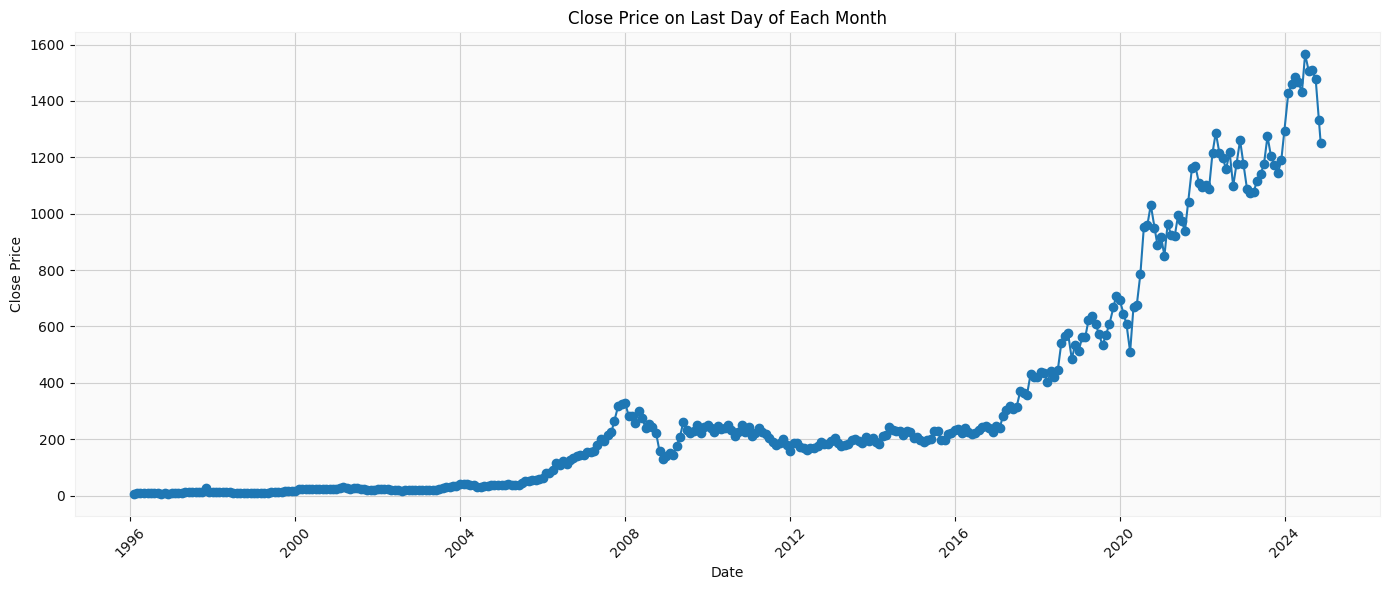

In [ ]:
pd_df_month_end = df_cleaned.select("Date", "Close").toPandas()

pd_df_month_end['Date'] = pd.to_datetime(pd_df_month_end['Date'])
pd_df_month_end = pd_df_month_end.sort_values('Date')

pd_df_month_end['YearMonth'] = pd_df_month_end['Date'].dt.to_period('M')

last_day_df = pd_df_month_end.groupby('YearMonth').tail(1)

plt.figure(figsize=(14, 6))
plt.plot(last_day_df['Date'], last_day_df['Close'], marker='o', linestyle='-', color='#1f77b4')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Close Price on Last Day of Each Month')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


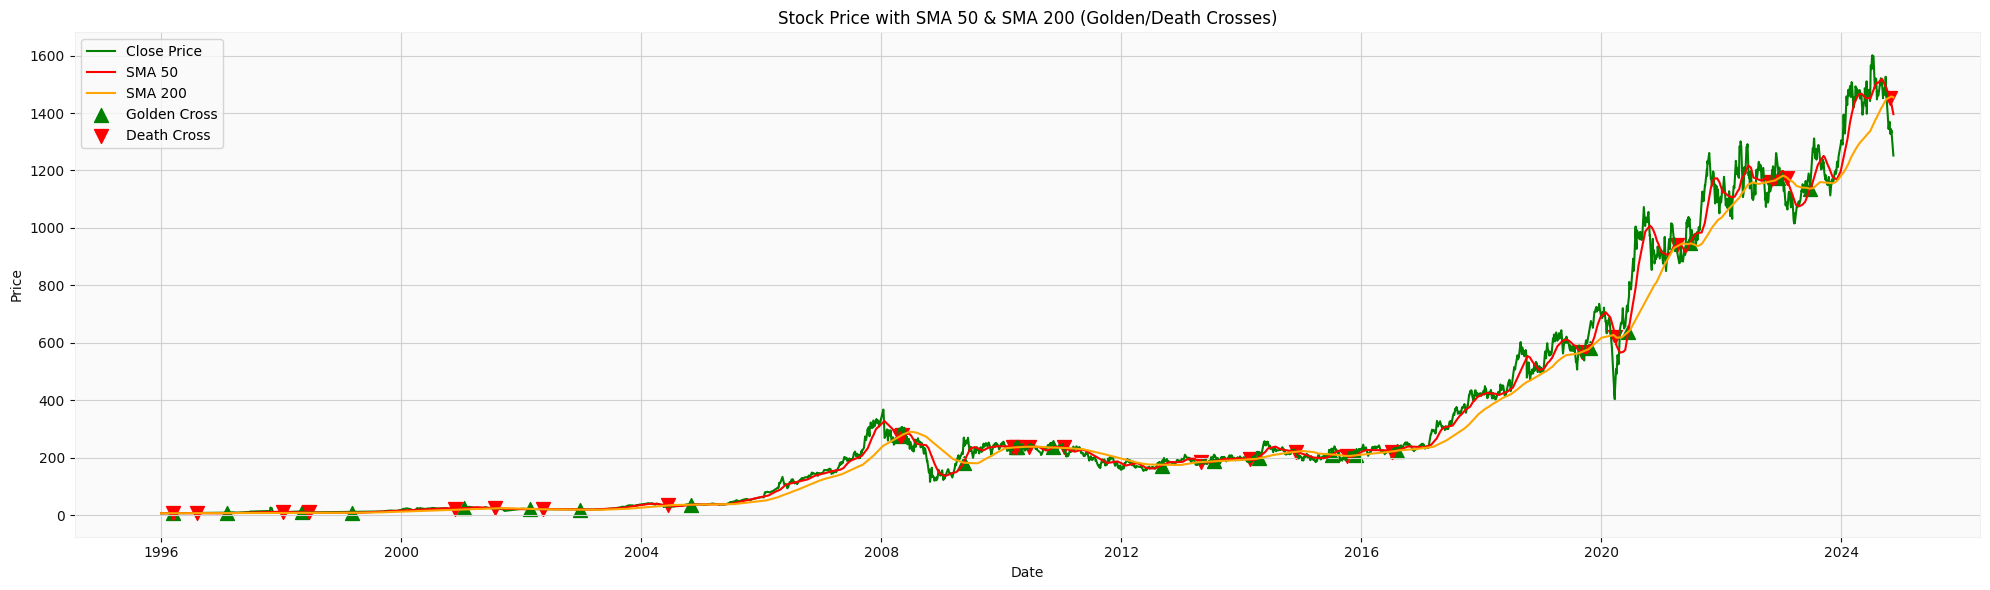

In [ ]:
pdf = df_cleaned.toPandas()

pdf['Date'] = pd.to_datetime(pdf['Date'])
pdf.set_index('Date', inplace=True)

pdf['GoldenCross'] = (pdf['SMA_50'] > pdf['SMA_200']) & (pdf['SMA_50'].shift(1) <= pdf['SMA_200'].shift(1))

pdf['DeathCross'] = (pdf['SMA_50'] < pdf['SMA_200']) & (pdf['SMA_50'].shift(1) >= pdf['SMA_200'].shift(1))

plt.figure(figsize=(20,6))
plt.plot(pdf.index, pdf['Close'], label='Close Price', color='green')
plt.plot(pdf.index, pdf['SMA_50'], label='SMA 50', color='red')
plt.plot(pdf.index, pdf['SMA_200'], label='SMA 200', color='orange')

plt.scatter(pdf.index[pdf['GoldenCross']], pdf['SMA_50'][pdf['GoldenCross']],
            marker='^', color='green', s=100, label='Golden Cross')

plt.scatter(pdf.index[pdf['DeathCross']], pdf['SMA_50'][pdf['DeathCross']],
            marker='v', color='red', s=100, label='Death Cross')

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price with SMA 50 & SMA 200 (Golden/Death Crosses)")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

**The Golden Cross is a bullish signal where the 50-day moving average crosses above the 200-day moving average, while the Death Cross is a bearish signal where the 50-day moving average crosses below the 200-day moving average.**

---

### 🟡 Golden Cross
- **Definition**: Occurs when a **short-term moving average (typically 50-day SMA)** crosses **above** a long-term moving average (typically 200-day SMA).
- **Signal**: Indicates a potential **long-term uptrend** or bull market.
- **Investor Sentiment**: Traders often see this as a **buy signal**, suggesting momentum is shifting upward.
- **Example**: If a stock’s 50-day SMA rises above its 200-day SMA, it suggests strengthening price action and possible sustained growth.

---

### ⚫ Death Cross
- **Definition**: Occurs when the **50-day SMA** crosses **below** the **200-day SMA**.
- **Signal**: Indicates a potential **long-term downtrend** or bear market.
- **Investor Sentiment**: Traders often see this as a **sell signal**, suggesting momentum is weakening.
- **Example**: If a stock’s 50-day SMA falls under its 200-day SMA, it suggests declining price action and possible extended losses.

---

### 📊 Why They Matter
- Both are **trend-following indicators** used in technical analysis.
- They are more reliable on **longer timeframes** (daily/weekly charts).
- Best used in combination with other indicators (volume, RSI, MACD) to avoid false signals.

KEY FINDINGS :    



*   OVERALL NON-VOLATILE STOCK
*   GOOD FOR LONG TERM INVESTMENT (BASES ON THIS ANALYSIS)


*   REACHED ALL TIME HIGH IN JUNE 2024
*   SAW THREE BEARISH PERIOD DURING 2007 , 2019 AND 2024


*   GONE FROM 7 INR TO ALL TIME HIGH OF INR 1608 IN JUNE 2024


*   THERE WAS A RAPID INCREASE IN PRICE AFTER LOCKDOWN
*   RISKY FOR SHORT-TERM INVESTMENTS (BASED ON THIS ANALYSIS)












